# 01 · Exploratory Data Analysis

**Global Government Budgets, 1936–2026 (45 countries).**

This notebook establishes what the dataset contains, verifies its integrity, and surfaces first-order structure: coverage, distributions, and sanity checks. It is the foundation the other notebooks build on.

> Amounts are in **nominal USD billions** (not inflation-adjusted). Percentages are each category's share of that country-year's total budget.

In [1]:
import sys
from pathlib import Path
# Locate the project root (the folder containing src/globalbudget) and add src to path.
_p = Path.cwd()
while _p != _p.parent and not (_p / "src" / "globalbudget").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from globalbudget import data_loader, cleaning, features, viz, forecasting
viz.set_theme()
pd.set_option("display.max_columns", 40)
print("Project root:", _p)


Project root: /Users/shrutichougule/Documents/global budget


## 1. Load & shape

In [2]:
wide = data_loader.load_master()
print('Shape:', wide.shape)
print('Countries:', wide.Country.nunique(), '| Years:', wide.Year.min(), '-', wide.Year.max())
wide.head()

Shape: (3654, 21)
Countries: 45 | Years: 1936 - 2026


,Country,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage,Defense_Amount_Billions_USD,Education_Amount_Billions_USD,Health_Amount_Billions_USD,Interest_Payments_Amount_Billions_USD,Infrastructure_Amount_Billions_USD,Agriculture_Amount_Billions_USD,State_Transfers_Amount_Billions_USD,Social_Welfare_Amount_Billions_USD,Administration_and_Others_Amount_Billions_USD
0,Argentina,1946,5.78,15.4,17.82,8.65,1.552,13.09,7.85,10.47,10.47,10.47,0.090,0.239,0.276,0.134,0.203,0.122,0.162,0.162,0.162
1,Argentina,1947,5.78,15.4,17.82,8.65,1.629,13.09,7.85,10.47,10.47,10.47,0.094,0.251,0.290,0.141,0.213,0.128,0.171,0.171,0.171
2,Argentina,1948,5.78,15.4,17.82,8.65,1.711,13.09,7.85,10.47,10.47,10.47,0.099,0.263,0.305,0.148,0.224,0.134,0.179,0.179,0.179
3,Argentina,1949,5.78,15.4,17.82,8.65,1.796,13.09,7.85,10.47,10.47,10.47,0.104,0.277,0.320,0.155,0.235,0.141,0.188,0.188,0.188
4,Argentina,1950,5.78,15.4,17.82,8.65,1.886,13.09,7.85,10.47,10.47,10.47,0.109,0.290,0.336,0.163,0.247,0.148,0.197,0.197,0.197


In [3]:
wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3654 non-null   string 
 1   Year                                           3654 non-null   int64  
 2   Defense_Percentage                             3654 non-null   float64
 3   Education_Percentage                           3654 non-null   float64
 4   Health_Percentage                              3654 non-null   float64
 5   Interest_Payments_Percentage                   3654 non-null   float64
 6   Total_Budget_Billions_USD                      3654 non-null   float64
 7   Infrastructure_Percentage                      3654 non-null   float64
 8   Agriculture_Percentage                         3654 non-null   float64
 9   State_Transfers_Percentage                     3654 

## 2. Integrity checks
Missing values, duplicate country-years, percentage sums, and negative amounts.

In [4]:
report = cleaning.validate(wide)
pd.Series(report).to_frame('value')

,value
missing_values,0.00
duplicate_country_years,0.00
rows_pct_not_100,0.00
pct_sum_min,99.97
pct_sum_max,100.03
negative_amounts,0.00
n_rows,3654.00
n_countries,45.00
year_min,1936.00
year_max,2026.00


Percentages sum to ~100 for every row (small rounding), there are **no missing values**, and **no duplicate country-years** — the validator would have raised otherwise.

## 3. Coverage per country
Countries start in different years (e.g. USA/UK 1936, China 1950, Germany 1949).

In [5]:
coverage = wide.groupby('Country').Year.agg(['min','max','count']).sort_values('min')
coverage.head(10)

,min,max,count
Country,,,
USA,1936,2026,91
UK,1936,2026,91
Argentina,1946,2026,81
Nigeria,1946,2026,81
Pakistan,1946,2026,81
Peru,1946,2026,81
Philippines,1946,2026,81
Poland,1946,2026,81
Portugal,1946,2026,81


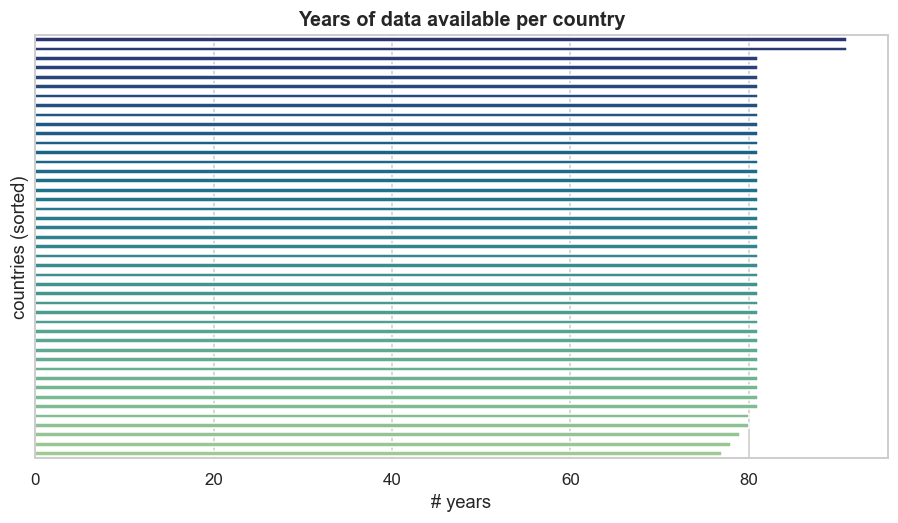

In [6]:
fig, ax = plt.subplots(figsize=(10,5))
coverage['count'].sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('crest', len(coverage)))
ax.set_title('Years of data available per country'); ax.set_xlabel('# years')
ax.set_yticks([]); ax.set_ylabel('countries (sorted)')
viz.save(fig, 'eda_coverage'); plt.show()

## 4. Total budget distribution
Budgets span several orders of magnitude, so we view them on a log scale.

/var/folders/kl/xff32qmd53g6jyxg8pqykph40000gn/T/ipykernel_8838/3714711758.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y='Country', x='Total_Budget_Billions_USD', ax=axes[1], palette='flare')


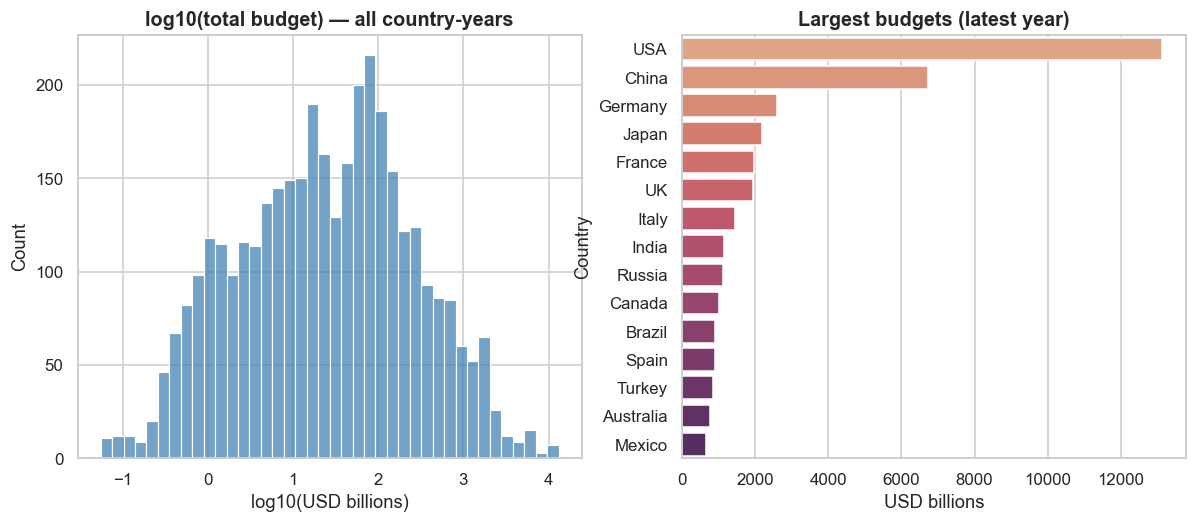

In [7]:
latest = wide.sort_values('Year').groupby('Country').tail(1)
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(np.log10(wide['Total_Budget_Billions_USD']), bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('log10(total budget) — all country-years'); axes[0].set_xlabel('log10(USD billions)')
top = latest.nlargest(15, 'Total_Budget_Billions_USD')
sns.barplot(data=top, y='Country', x='Total_Budget_Billions_USD', ax=axes[1], palette='flare')
axes[1].set_title('Largest budgets (latest year)'); axes[1].set_xlabel('USD billions')
viz.save(fig, 'eda_budget_distribution'); plt.show()

## 5. Category shares — distribution across all country-years
How much of a budget each function typically absorbs.

/var/folders/kl/xff32qmd53g6jyxg8pqykph40000gn/T/ipykernel_8838/893865136.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long, x='Percentage', y='Category', order=order, ax=ax, palette='colorblind')


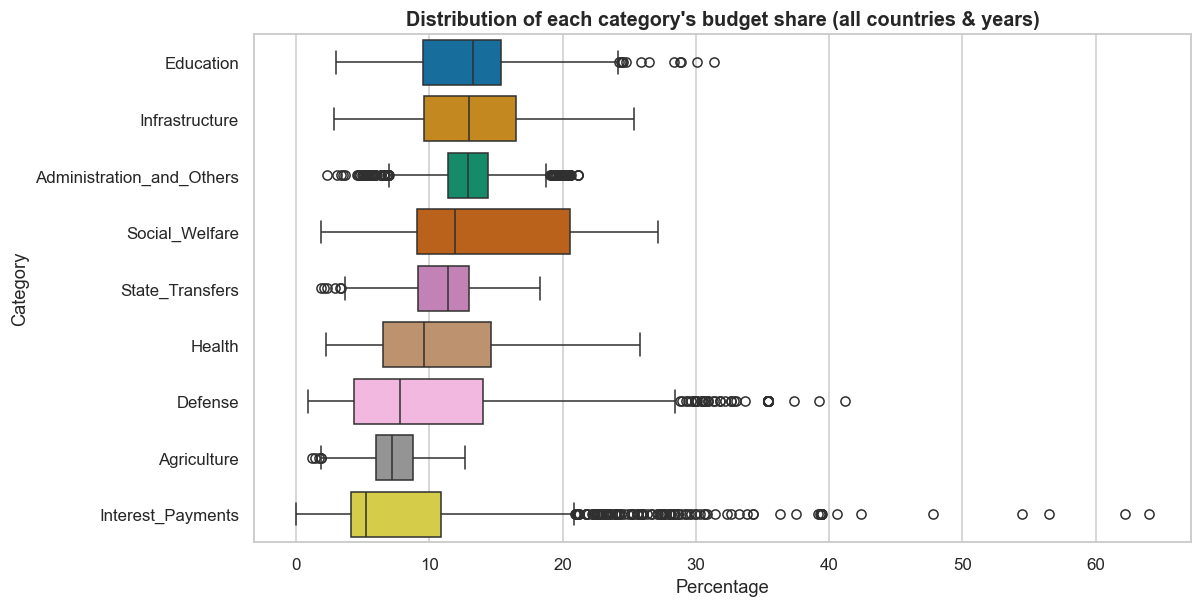

In [8]:
long = cleaning.to_long(wide)
fig, ax = plt.subplots(figsize=(11,6))
order = long.groupby('Category', observed=True).Percentage.median().sort_values(ascending=False).index
sns.boxplot(data=long, x='Percentage', y='Category', order=order, ax=ax, palette='colorblind')
ax.set_title('Distribution of each category\'s budget share (all countries & years)')
viz.save(fig, 'eda_category_boxplots'); plt.show()

In [9]:
long.groupby('Category', observed=True).Percentage.describe()[['mean','50%','min','max']].round(2)

,mean,50%,min,max
Category,,,,
Defense,9.68,7.80,0.89,41.16
Education,12.79,13.25,2.98,31.37
Health,10.35,9.61,2.22,25.84
Interest_Payments,8.33,5.26,0.00,63.98
Infrastructure,13.37,12.97,2.88,25.39
Agriculture,7.22,7.18,1.17,12.70
State_Transfers,11.11,11.40,1.84,18.33
Social_Welfare,14.24,11.94,1.84,27.16
Administration_and_Others,12.92,12.91,2.30,21.16


## Takeaways
* Clean panel: 45 countries × up to 91 years, no missing values, shares sum to 100.
* Budgets are heavily right-skewed — a handful of economies dominate global spending.
* Social-facing functions (health, education, welfare, transfers) command the largest median shares; agriculture and interest are typically the smallest.

Next: **02_visualization** for the temporal and compositional story.